# Heart Disease UCI - Exploratory Data Analysis

**MLOps Assignment 01** | Dataset: Heart Disease UCI (Cleveland), 303 records, 13 features + binary target.

This notebook covers:
1. Data loading & structure
2. Missing-value analysis
3. Target class balance
4. Feature distributions (histograms)
5. Correlation heatmap
6. Feature-vs-target relationships

All figures are also saved to `notebooks/figures/` for the report.

In [1]:
import sys, os
from pathlib import Path

# Make the project root importable (so `import src...` works from notebooks/).
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

FIG_DIR = ROOT / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

from src import config
df = pd.read_csv(config.DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 1. Data structure & summary statistics

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 2. Missing-value analysis

The UCI Cleveland data uses `?` for missing values (already converted to `NaN`
by the download script). Only `ca` and `thal` contain a handful of missing cells.

Columns with missing values:
ca      4
thal    2
dtype: int64


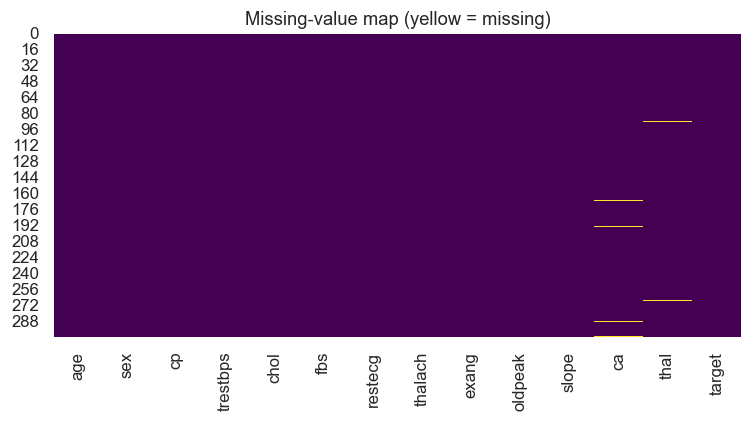

In [4]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing if len(missing) else "None")

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(df.isna(), cbar=False, cmap="viridis", ax=ax)
ax.set_title("Missing-value map (yellow = missing)")
fig.tight_layout()
fig.savefig(FIG_DIR / "missing_values.png")
plt.show()

## 3. Target class balance

`target`: 0 = no heart disease, 1 = disease present. The classes are reasonably
balanced, so accuracy is a meaningful metric (we still report precision/recall/AUC).

target
0    164
1    139
Name: count, dtype: int64
Balance (%):
target
0    54.1
1    45.9
Name: count, dtype: float64


C:\Users\kumars8\AppData\Local\Temp\ipykernel_32804\2039198474.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df, ax=ax, palette=["#4C9F70", "#D1495B"])
C:\Users\kumars8\AppData\Local\Temp\ipykernel_32804\2039198474.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Disease (0)", "Disease (1)"])


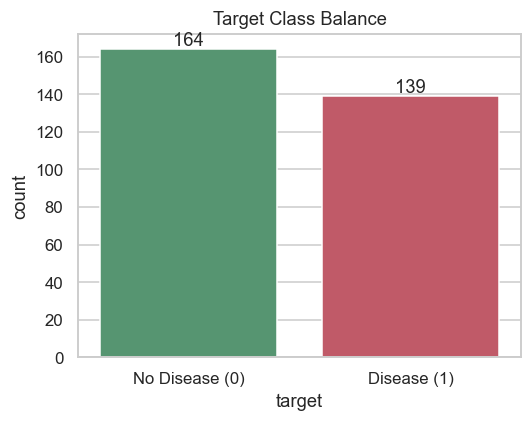

In [5]:
counts = df["target"].value_counts().sort_index()
print(counts)
print("Balance (%):")
print((counts / counts.sum() * 100).round(1))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="target", data=df, ax=ax, palette=["#4C9F70", "#D1495B"])
ax.set_xticklabels(["No Disease (0)", "Disease (1)"])
ax.set_title("Target Class Balance")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
fig.tight_layout()
fig.savefig(FIG_DIR / "class_balance.png")
plt.show()

## 4. Feature distributions (histograms)

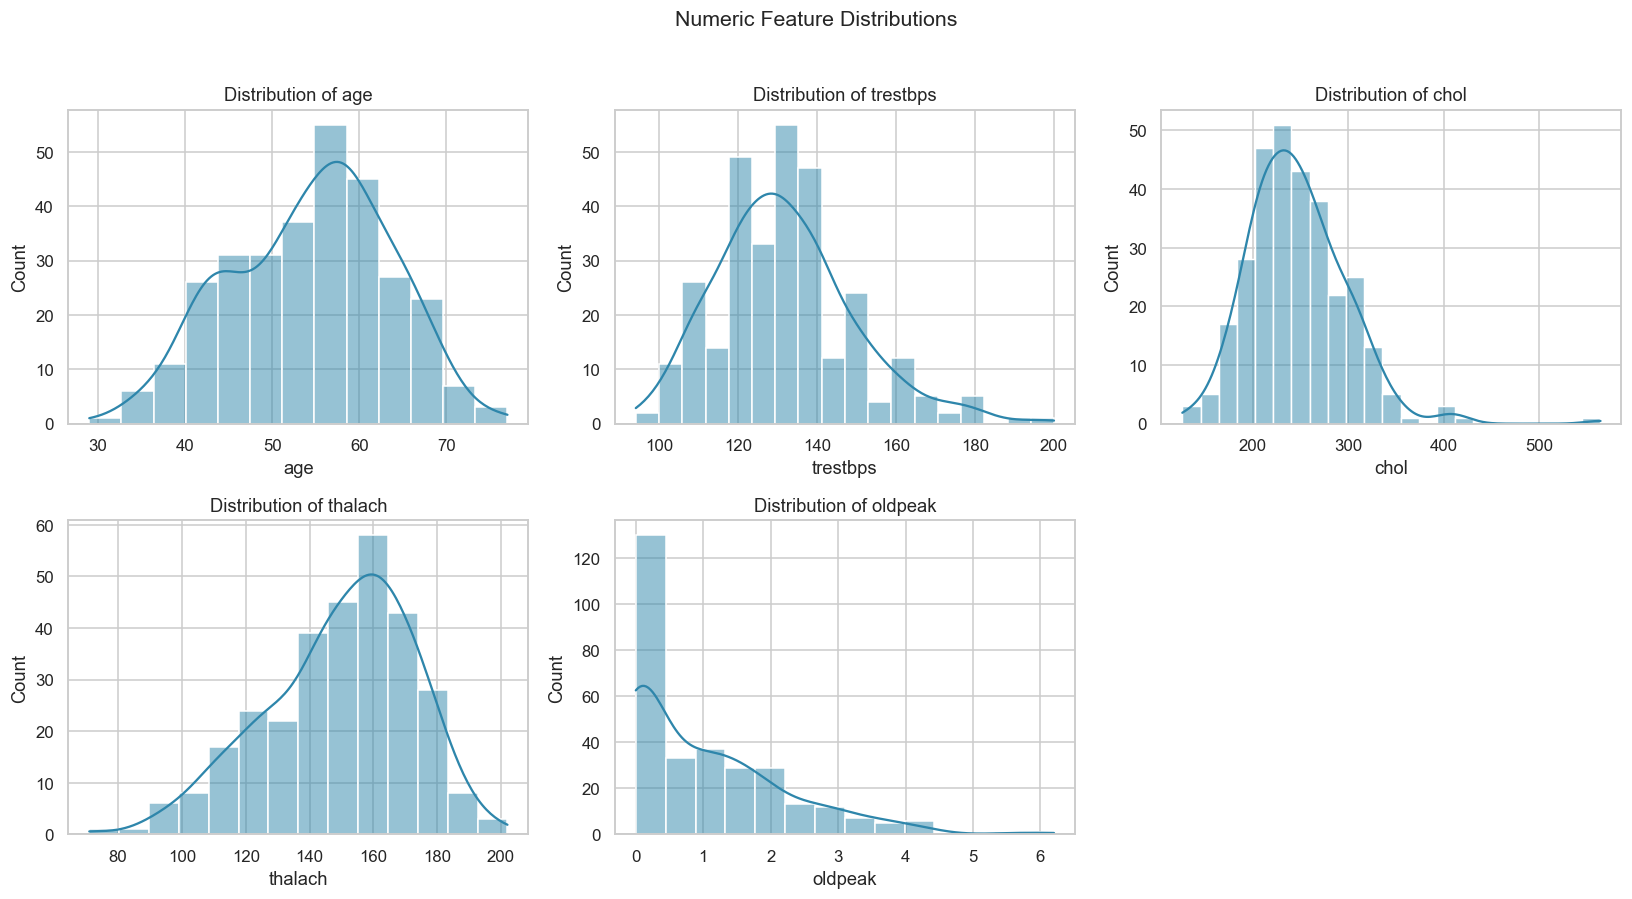

In [6]:
num_cols = config.NUMERIC_FEATURES
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="#2E86AB")
    ax.set_title(f"Distribution of {col}")
# hide any unused subplot
for ax in axes.ravel()[len(num_cols):]:
    ax.set_visible(False)
fig.suptitle("Numeric Feature Distributions", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "histograms.png", bbox_inches="tight")
plt.show()

Categorical / discrete feature counts:

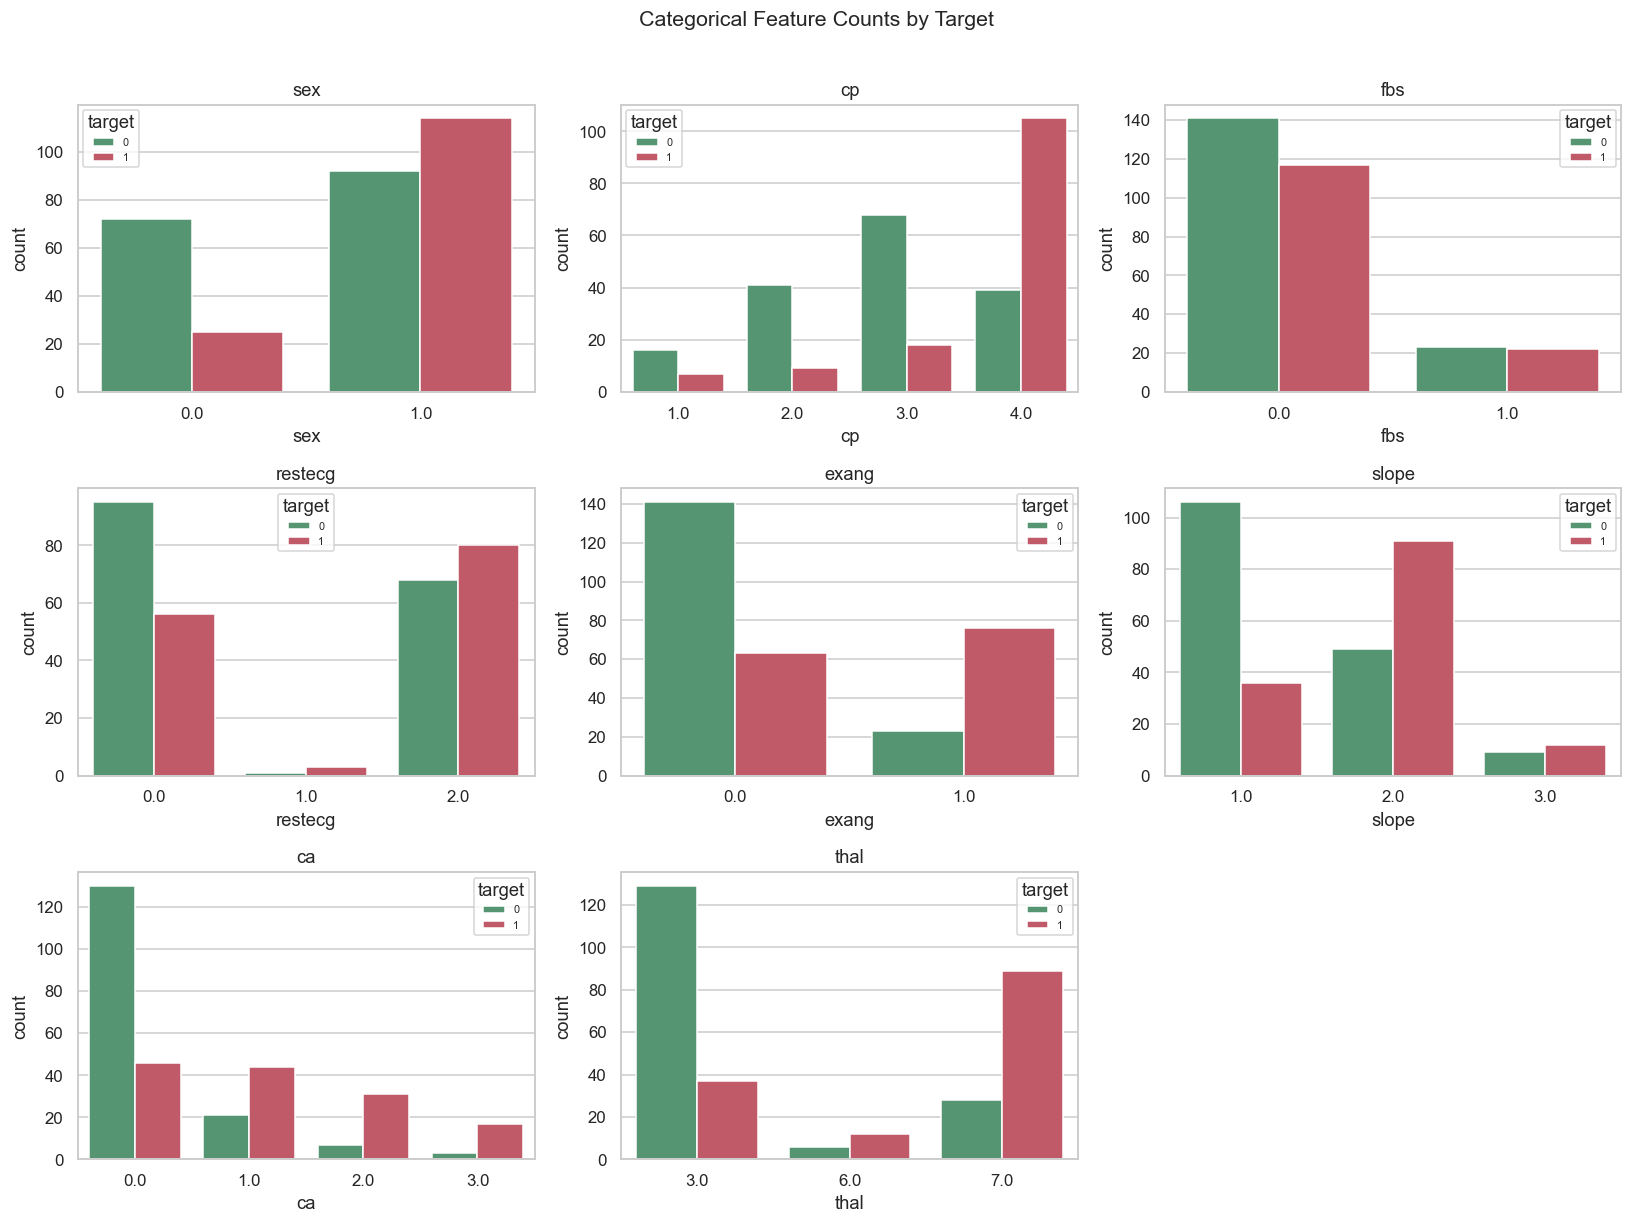

In [7]:
cat_cols = config.CATEGORICAL_FEATURES
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.ravel(), cat_cols):
    sns.countplot(x=col, data=df, ax=ax, hue="target", palette=["#4C9F70", "#D1495B"])
    ax.set_title(col)
    ax.legend(title="target", fontsize=7)
for ax in axes.ravel()[len(cat_cols):]:
    ax.set_visible(False)
fig.suptitle("Categorical Feature Counts by Target", y=1.01, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "categorical_counts.png", bbox_inches="tight")
plt.show()

## 5. Correlation heatmap

Pearson correlation across all features and the target. `cp` (chest pain type),
`thalach` (max heart rate), `oldpeak`, `ca` and `exang` show the strongest
association with the target.

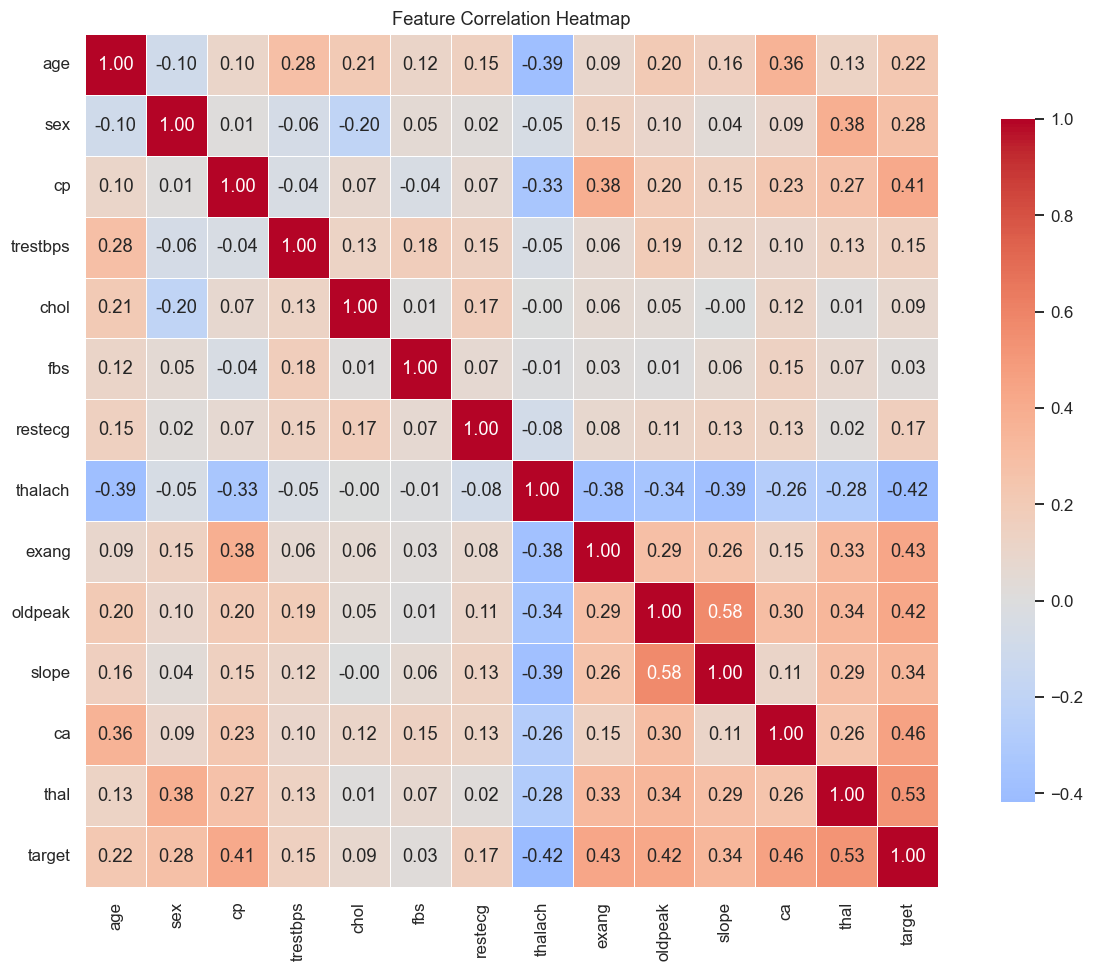

In [8]:
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Heatmap")
fig.tight_layout()
fig.savefig(FIG_DIR / "correlation_heatmap.png", bbox_inches="tight")
plt.show()

In [9]:
# Correlation of each feature with the target, ranked.
target_corr = corr["target"].drop("target").sort_values(key=abs, ascending=False)
print("Feature correlation with target (by |r|):")
print(target_corr.round(3))

Feature correlation with target (by |r|):
thal        0.526
ca          0.460
exang       0.432
oldpeak     0.425
thalach    -0.417
cp          0.414
slope       0.339
sex         0.277
age         0.223
restecg     0.169
trestbps    0.151
chol        0.085
fbs         0.025
Name: target, dtype: float64


## 6. Feature-vs-target relationships

How the most predictive numeric features differ between the two classes.

C:\Users\kumars8\AppData\Local\Temp\ipykernel_32804\2536725319.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y=col, data=df, ax=ax, palette=["#4C9F70", "#D1495B"])
C:\Users\kumars8\AppData\Local\Temp\ipykernel_32804\2536725319.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])
C:\Users\kumars8\AppData\Local\Temp\ipykernel_32804\2536725319.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y=col, data=df, ax=ax, palette=["#4C9F70", "#D1495B"])
C:\Users\kumars8\AppData\Local\Temp\ipykernel_32804\2536725319.py:5: UserWarning: set_ticklabels() sh

C:\Users\kumars8\AppData\Local\Temp\ipykernel_32804\2536725319.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])
C:\Users\kumars8\AppData\Local\Temp\ipykernel_32804\2536725319.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="target", y=col, data=df, ax=ax, palette=["#4C9F70", "#D1495B"])
C:\Users\kumars8\AppData\Local\Temp\ipykernel_32804\2536725319.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])


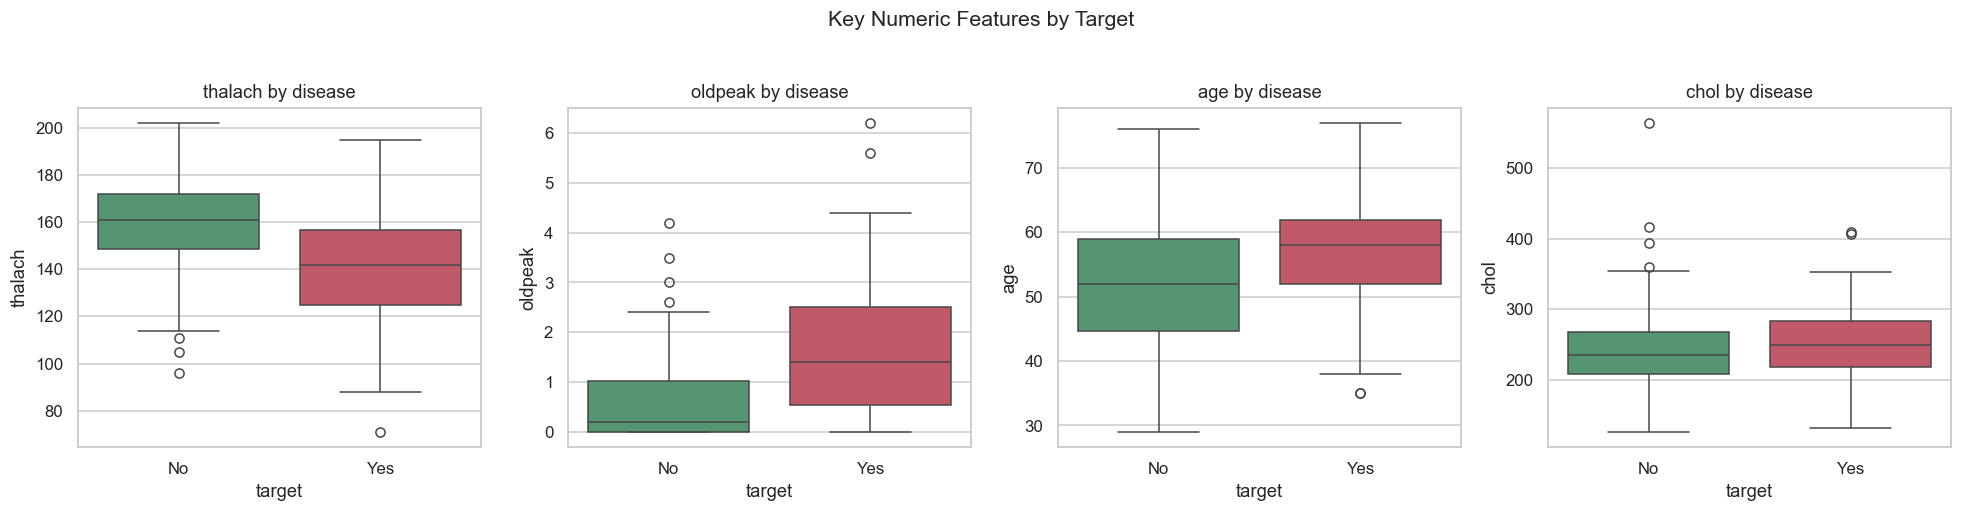

In [10]:
key_feats = ["thalach", "oldpeak", "age", "chol"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, col in zip(axes, key_feats):
    sns.boxplot(x="target", y=col, data=df, ax=ax, palette=["#4C9F70", "#D1495B"])
    ax.set_xticklabels(["No", "Yes"])
    ax.set_title(f"{col} by disease")
fig.suptitle("Key Numeric Features by Target", y=1.03, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "feature_vs_target.png", bbox_inches="tight")
plt.show()

## Key EDA findings

- **303 records, 13 features, binary target**; classes fairly balanced (~54% / 46%).
- **Missing values** only in `ca` and `thal` (a few cells) - handled by imputation in the pipeline.
- **Strongest predictors** (by |correlation| and boxplot separation): chest pain type (`cp`),
  max heart rate (`thalach`, negatively correlated), ST depression (`oldpeak`),
  number of major vessels (`ca`), and exercise-induced angina (`exang`).
- **No aggressive outlier removal** was applied; tree models are robust and the
  standard scaler handles the linear model - documented in the report.